# ForecastLab — EXP-007 Linear Regression

| Informasi | Detail |
|-----------|--------|
| **Project ID** | FL-002 |
| **Eksperimen** | EXP-007 |
| **Dataset** | featured_data.csv |
| **Author** | GAKUSEI Najib |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

INPUT_PATH = '../data/featured_data.csv'
df = pd.read_csv(INPUT_PATH)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

target = 'PowerConsumption_Zone1'
exclude = ['Datetime', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']
feature_cols = [c for c in df.columns if c not in exclude and c != target]

train = df[df['Datetime'] < '2017-07-01']
test  = df[df['Datetime'] >= '2017-07-01']
X_train, y_train = train[feature_cols].fillna(0), train[target]
X_test, y_test = test[feature_cols].fillna(0), test[target]
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

X_train: (25920, 43), X_test: (26352, 43)


In [2]:
t0 = time.time()
model = LinearRegression()
model.fit(X_train, y_train)
train_time = time.time() - t0

y_pred_test = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mape = np.mean(np.abs((y_test - y_pred_test) / (y_test + 1e-10))) * 100
r2 = r2_score(y_test, y_pred_test)
print(f'Linear Regression: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.1f}%, R2={r2:.4f} ({train_time:.2f}s)')

Linear Regression: MAE=242.17, RMSE=331.93, MAPE=0.8%, R2=0.9979 (0.04s)


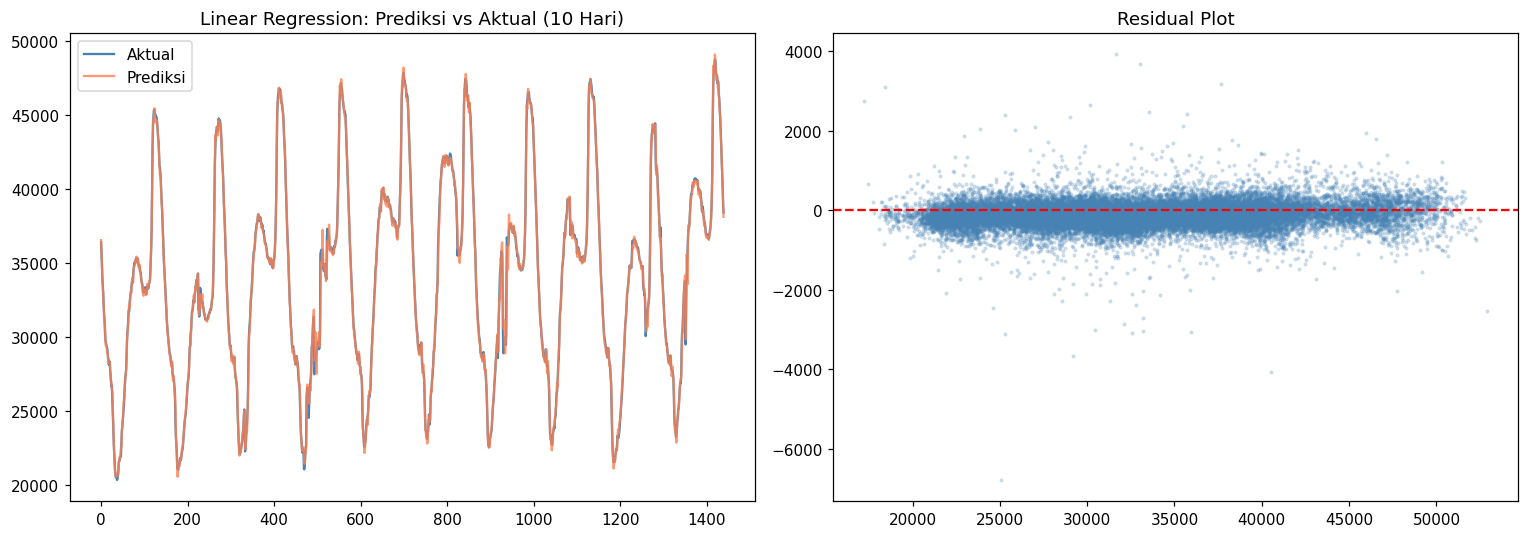

In [3]:
n_show = 1440
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(n_show), y_test.values[:n_show], label='Aktual', color='steelblue')
axes[0].plot(range(n_show), y_pred_test[:n_show], label='Prediksi', color='coral', alpha=0.8)
axes[0].set_title('Linear Regression: Prediksi vs Aktual (10 Hari)')
axes[0].legend()
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.2, s=3, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residual Plot')
plt.tight_layout()
plt.savefig('../data/lr_01_prediction.png', bbox_inches='tight', dpi=110)
plt.show()

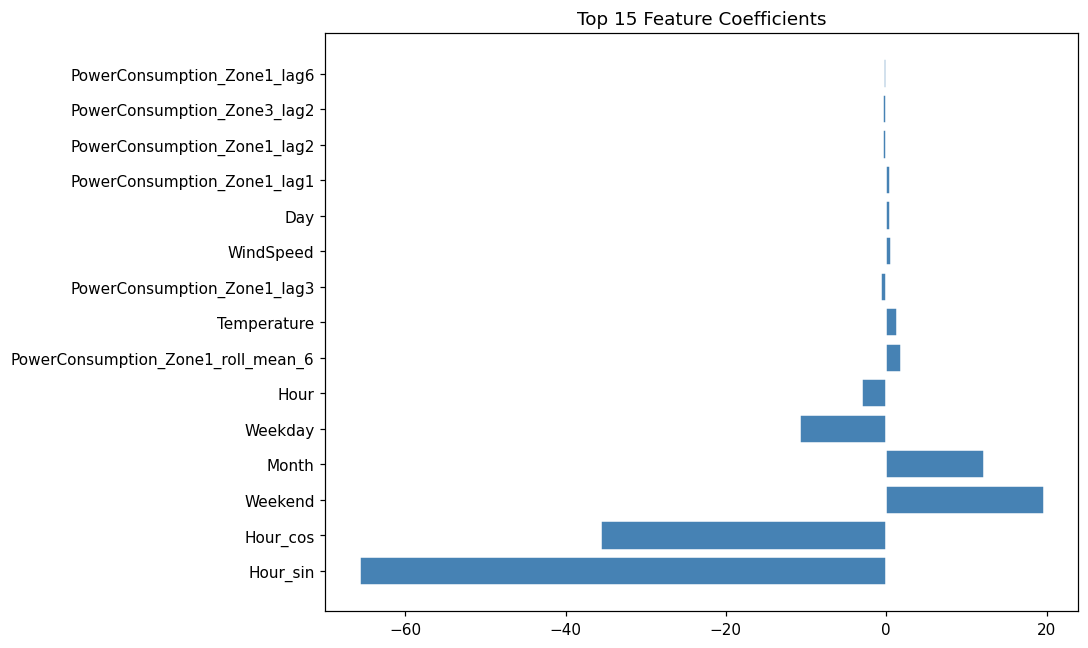

In [4]:
coef = pd.DataFrame({'Feature': feature_cols, 'Coefficient': model.coef_})
coef = coef.reindex(coef['Coefficient'].abs().sort_values(ascending=False).index)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(coef['Feature'][:15], coef['Coefficient'][:15], color='steelblue', edgecolor='white')
ax.set_title('Top 15 Feature Coefficients')
plt.tight_layout()
plt.savefig('../data/lr_02_coefficients.png', bbox_inches='tight', dpi=110)
plt.show()

---
## Kesimpulan

Linear Regression sebagai baseline ML. Feature terpenting: lag values, temperature, hour.

**Next: EXP-008 Decision Tree**